In [ ]:
# 🐶🐱 Dogs vs Cats Image Classification using CNN

This project implements multiple Convolutional Neural Network (CNN) models to classify images of dogs and cats.

The objective is to experiment with different CNN architectures and compare them with a transfer learning approach using MobileNetV2.

Models implemented:
- Baseline CNN
- Larger CNN
- Tuned CNN (Dropout + smaller learning rate)
- Transfer Learning (MobileNetV2)

Best Validation Accuracy: **97.52%**

Author: Jenish Bhati

In [ ]:
import zipfile
import os

zip_path = "archive.zip"   # dataset zip file placed in project folder

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("./")

In [ ]:
## 2. Dataset Cleaning
# The dataset contains some corrupted images.
# These images were detected and removed using PIL verification.

from PIL import Image
import os

dataset_path = "PetImages"

for folder in ["Cat", "Dog"]:
    folder_path = os.path.join(dataset_path, folder)

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        try:
            img = Image.open(file_path)
            img.verify()
        except:
            os.remove(file_path)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [ ]:
## 3. Data Preprocessing
# Preprocessing steps:
# - Resize images to 224×224
# - Normalize pixel values to [0,1]
# - Apply data augmentation
# - 80/20 Train-Validation split

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image size and batch size
# 224x224 chosen to match transfer learning models later
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ImageDataGenerator handles:
# - Normalization (rescale pixel values 0–255 → 0–1)
# - Data augmentation (helps reduce overfitting)
# - Automatic train/validation split
datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values
    validation_split=0.2,        # 80% training, 20% validation
    rotation_range=20,           # Random rotation
    zoom_range=0.2,              # Random zoom
    horizontal_flip=True         # Random horizontal flip
)

# Training data generator
train_generator = datagen.flow_from_directory(
    dataset_path,        # Dataset path
    target_size=IMG_SIZE,        # Resize all images to 224x224
    batch_size=BATCH_SIZE,
    class_mode='binary',         # Binary classification (Cat vs Dog)
    subset='training'            # Use 80% data for training
)

# Validation data generator
validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'          # Use 20% data for validation
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [ ]:
## 4. Scratch CNN Models
# A parameterized CNN builder function was created to allow structured experimentation with:
# - Filter size
# - Dropout
# - Learning rate

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# This function builds a CNN model based on given parameters
def build_model(filters, dropout_rate, learning_rate):

    model = Sequential()

    # ---- Convolution Block 1 ----
    # Extract low-level features (edges, textures)
    model.add(Conv2D(filters[0], (3,3), activation='relu', input_shape=(224,224,3)))
    model.add(MaxPooling2D(2,2))  # Reduce spatial dimensions

    # ---- Convolution Block 2 ----
    # Extract more complex patterns
    model.add(Conv2D(filters[1], (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))

    # ---- Convolution Block 3 ----
    # Higher-level feature extraction
    model.add(Conv2D(filters[2], (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))

    # Flatten 2D feature maps into 1D vector
    model.add(Flatten())

    # Fully connected layer for learning complex relationships
    model.add(Dense(128, activation='relu'))

    # Optional dropout for regularization
    # Helps reduce overfitting
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Output layer
    # Sigmoid for binary classification
    model.add(Dense(1, activation='sigmoid'))

    # Define optimizer with chosen learning rate
    optimizer = Adam(learning_rate=learning_rate)

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',  # Suitable for binary classification
        metrics=['accuracy']
    )

    return model

In [ ]:
# Model 1: Baseline CNN
# - Standard filter sizes
# - No dropout
# - Default learning rate

model1 = build_model(
    filters=[32, 64, 128],   # Increasing filters in deeper layers
    dropout_rate=0.0,        # No regularization
    learning_rate=0.001      # Default Adam learning rate
)

history1 = model1.fit(
    train_generator,
    epochs=5,               # Moderate number of epochs
    validation_data=validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
607/625 ━━━━━━━━━━━━━━━━━━━━ 7s 403ms/step - accuracy: 0.5851 - loss: 0.7312

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 322s 503ms/step - accuracy: 0.5865 - loss: 0.7287 - val_accuracy: 0.7135 - val_loss: 0.5733
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 306s 489ms/step - accuracy: 0.6974 - loss: 0.5686 - val_accuracy: 0.7457 - val_loss: 0.5054
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 311s 497ms/step - accuracy: 0.7614 - loss: 0.4855 - val_accuracy: 0.7861 - val_loss: 0.4593
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 306s 490ms/step - accuracy: 0.7896 - loss: 0.4480 - val_accuracy: 0.7967 - val_loss: 0.4390
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 306s 489ms/step - accuracy: 0.8046 - loss: 0.4235 - val_accuracy: 0.8181 - val_loss: 0.4146


In [ ]:
# Model 2: Increased model complexity
# - More filters → better feature extraction
# - Still no dropout

model2 = build_model(
    filters=[64, 128, 256],  # Increased filters
    dropout_rate=0.0,
    learning_rate=0.001
)

history2 = model2.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 335s 520ms/step - accuracy: 0.5827 - loss: 0.7239 - val_accuracy: 0.7255 - val_loss: 0.5508
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 321s 514ms/step - accuracy: 0.7235 - loss: 0.5474 - val_accuracy: 0.7611 - val_loss: 0.4879
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 319s 509ms/step - accuracy: 0.7730 - loss: 0.4752 - val_accuracy: 0.7991 - val_loss: 0.4349
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 324s 512ms/step - accuracy: 0.7883 - loss: 0.4390 - val_accuracy: 0.8105 - val_loss: 0.4311
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 318s 509ms/step - accuracy: 0.8209 - loss: 0.3909 - val_accuracy: 0.7885 - val_loss: 0.4445


In [ ]:
# Model 3: Regularization + Smaller Learning Rate
# - Same filters as Model 2
# - Add dropout to reduce overfitting
# - Lower learning rate for smoother convergence

model3 = build_model(
    filters=[64, 128, 256],
    dropout_rate=0.5,        # Strong regularization
    learning_rate=0.0001     # Smaller learning rate
)

history3 = model3.fit(
    train_generator,
    epochs=10,               # More epochs since LR is small
    validation_data=validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
382/625 ━━━━━━━━━━━━━━━━━━━━ 1:42 420ms/step - accuracy: 0.5682 - loss: 0.6732

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 330s 521ms/step - accuracy: 0.5955 - loss: 0.6552 - val_accuracy: 0.7373 - val_loss: 0.5303
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 321s 513ms/step - accuracy: 0.7230 - loss: 0.5447 - val_accuracy: 0.7609 - val_loss: 0.5013
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 322s 515ms/step - accuracy: 0.7524 - loss: 0.5015 - val_accuracy: 0.7661 - val_loss: 0.4824
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 327s 523ms/step - accuracy: 0.7851 - loss: 0.4722 - val_accuracy: 0.8063 - val_loss: 0.4233
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 321s 513ms/step - accuracy: 0.7979 - loss: 0.4316 - val_accuracy: 0.8111 - val_loss: 0.4204
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 319s 510ms/step - accuracy: 0.8065 - loss: 0.4219 - val_accuracy: 0.8169 - val_loss: 0.3951
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 321s 514ms/step - accuracy: 0.8194 - loss: 0.4018 - val_accuracy: 0.8333 - val_loss: 0.3740
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 320s 512ms/step - accuracy: 0.8328 - loss: 0.38

In [ ]:
## 5. Transfer Learning – MobileNetV2
# A pretrained MobileNetV2 model trained on ImageNet was used.
# Base layers were frozen and a custom classification head was added.

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam

# ---------------------------------------------------------
# Step 1: Load Pretrained Base Model
# ---------------------------------------------------------

# MobileNetV2 is pretrained on ImageNet (1M+ images)
# include_top=False removes the original 1000-class classifier
# input_shape must match our dataset (224x224x3)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers of the base model
# This prevents pretrained weights from being updated during training
# We only want to train our new classifier layers
base_model.trainable = False


# ---------------------------------------------------------
# Step 2: Add Custom Classification Head
# ---------------------------------------------------------

# Extract output feature maps from base model
x = base_model.output

# Convert 2D feature maps into 1D vector
# This reduces number of parameters compared to Flatten()
x = GlobalAveragePooling2D()(x)

# Fully connected layer for learning dataset-specific patterns
x = Dense(128, activation='relu')(x)

# Final output layer for binary classification
# Sigmoid outputs probability between 0 and 1
output = Dense(1, activation='sigmoid')(x)


# ---------------------------------------------------------
# Step 3: Create Final Model
# ---------------------------------------------------------

# Combine base model and new classification head
transfer_model = Model(inputs=base_model.input, outputs=output)


# ---------------------------------------------------------
# Step 4: Compile Model
# ---------------------------------------------------------

# Use small learning rate because pretrained features are sensitive
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',   # Suitable for binary classification
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
history_transfer = transfer_model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator
)

Epoch 1/5
541/625 ━━━━━━━━━━━━━━━━━━━━ 32s 385ms/step - accuracy: 0.9287 - loss: 0.1814

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 335s 508ms/step - accuracy: 0.9332 - loss: 0.1710 - val_accuracy: 0.9790 - val_loss: 0.0615
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 300s 480ms/step - accuracy: 0.9759 - loss: 0.0629 - val_accuracy: 0.9784 - val_loss: 0.0625
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 302s 483ms/step - accuracy: 0.9784 - loss: 0.0559 - val_accuracy: 0.9742 - val_loss: 0.0654
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 304s 486ms/step - accuracy: 0.9828 - loss: 0.0471 - val_accuracy: 0.9766 - val_loss: 0.0577
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 300s 480ms/step - accuracy: 0.9803 - loss: 0.0513 - val_accuracy: 0.9752 - val_loss: 0.0597


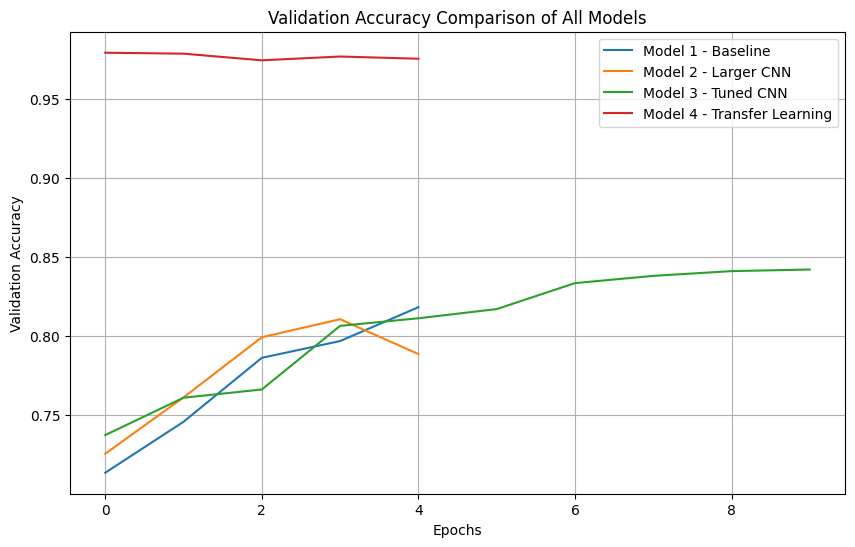

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(history1.history['val_accuracy'], label='Model 1 - Baseline')
plt.plot(history2.history['val_accuracy'], label='Model 2 - Larger CNN')
plt.plot(history3.history['val_accuracy'], label='Model 3 - Tuned CNN')
plt.plot(history_transfer.history['val_accuracy'], label='Model 4 - Transfer Learning')

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison of All Models")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## 6. Model Comparison

| Model | Description | Validation Accuracy |
|--------|------------|---------------------|
| Model 1 | Baseline CNN | 81.81% |
| Model 2 | Larger CNN | 78.85% |
| Model 3 | Tuned CNN | 84.19% |
| Model 4 | Transfer Learning | 97.52% |

Observation:
Transfer learning significantly outperformed scratch CNN models.

The transfer learning model significantly outperforms the CNN models trained from scratch.
This demonstrates the effectiveness of pretrained feature extractors in computer vision tasks.

In [ ]:
## 7. Testing on Custom Image
test_image_path = "test_dog.jpg"

Saving gettyimages-586890581.avif to gettyimages-586890581.avif


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def predict_image(model, img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    plt.imshow(img)
    plt.axis('off')

    if prediction > 0.5:
        print(f"Prediction: Dog ({prediction:.4f})")
    else:
        print(f"Prediction: Cat ({prediction:.4f})")

Model 1 Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediction: Dog (0.9512)
Model 2 Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: Dog (0.9528)
Model 3 Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction: Dog (0.9666)
Transfer Model Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: Dog (0.9996)


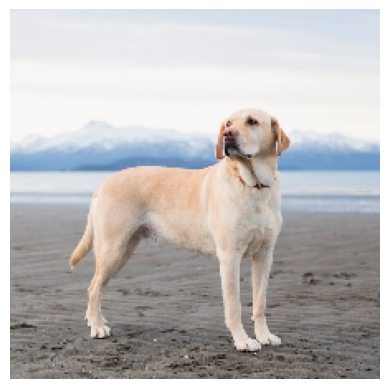

In [ ]:
print("Model 1 Prediction:")
predict_image(model1, test_image_path)

print("Model 2 Prediction:")
predict_image(model2, test_image_path)

print("Model 3 Prediction:")
predict_image(model3, test_image_path)

print("Transfer Model Prediction:")
predict_image(transfer_model, test_image_path)

In [ ]:
##8. Conclusion

- Increasing model capacity alone did not improve validation accuracy.
- Adding Dropout and reducing the learning rate improved generalization.
- Transfer learning using MobileNetV2 significantly outperformed CNN models trained from scratch.
- Pretrained models provide powerful feature extraction and faster convergence.

Final Best Validation Accuracy:
- Tuned CNN: **84.19%**
- Transfer Learning (MobileNetV2): **97.52%**